# Seed-1111 low-beta JPO values and restricted lower bounds

This notebook analyzes 80 unrestricted JPO training runs on MDP seed 1111: $S=6$, two receiver actions, $\gamma\in\{0.9,0.99\}$, $\beta\in\{0,0.05,0.10,0.15\}$, and ten $\epsilon$ values from 0.01 to 0.10. NativeSARSOP uses precision 0.01 and a nominal 500-second cap.

Every frozen normal policy is evaluated after training by deterministic joint state-belief propagation. If its reachable policy tree contains a violation, the post-hoc restricted controller is evaluated separately. Both value intervals target width $10^{-3}$; neither evaluation changes training.

In [51]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, SymLogNorm
from matplotlib.patches import Patch, Rectangle
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPOSITORY_ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'mdp.py').is_file()
)
ROOT = REPOSITORY_ROOT / 'experiments/jpo_low_beta_lb_s6_seed1111_g2_b4_e10_t500'
PLOTS = ROOT / 'plots'
PLOTS.mkdir(parents=True, exist_ok=True)
payload = json.loads((ROOT / 'results.json').read_text())
points = payload['points']
errors = [point for point in points if point['status'] != 'ok']
expected_points = payload['experiment']['expected_points']
assert not errors, errors[:3]
frame = pd.DataFrame(points).sort_values(['gamma', 'beta', 'epsilon']).reset_index(drop=True)
frame.to_csv(ROOT / 'grid_summary.csv', index=False)
violating = frame[frame['violation_count'] > 0].copy()
violating.to_csv(ROOT / 'violating_points.csv', index=False)
if len(frame) != expected_points:
    display(Markdown(f'**Partial analysis:** {len(frame)}/{expected_points} points are currently available.'))
len(frame), len(violating)

**Partial analysis:** 79/80 points are currently available.

(79, 29)

## Evaluation semantics

The normal value interval evaluates the frozen alpha-vector policy with its standard Bayesian posterior. The restricted interval is computed only when the normal policy violates. Its action rule stays frozen, but a non-revealing successful reception retains the null posterior instead of the Dirac posterior. The restricted interval's lower endpoint is therefore the value of a feasible post-hoc restricted controller, not a bound used by NativeSARSOP during training.

In [52]:
assert (frame['normal_policy_lower_bound'] <= frame['normal_policy_value']).all()
assert (frame['normal_policy_value'] <= frame['normal_policy_upper_bound']).all()
assert frame['normal_policy_interval_width'].max() <= 1.001e-3
assert (violating['restricted_lower_bound_status'] == 'ok').all()
assert violating['restricted_policy_lower_bound'].notna().all()
assert violating['restricted_policy_interval_width'].max() <= 1.001e-3
overview = (
    frame.groupby('gamma', as_index=False)
    .agg(
        policies=('point_id', 'size'),
        violating_policies=('violation_count', lambda values: int((values > 0).sum())),
        max_violation_count=('violation_count', 'max'),
        max_violation_occupancy=('violation_discounted_event_occupancy', 'max'),
        min_normal_value=('normal_policy_value', 'min'),
        max_normal_value=('normal_policy_value', 'max'),
        max_normal_nodes=('normal_policy_total_belief_nodes', 'max'),
        max_restricted_nodes=('restricted_policy_total_belief_nodes', 'max'),
        max_time_stops=('solver_stop_reason', lambda values: int((values == 'max_time').sum())),
    )
)
display(overview.round(8))
display(pd.crosstab(frame['gamma'], frame['solver_stop_reason']))

,gamma,policies,violating_policies,max_violation_count,max_violation_occupancy,min_normal_value,max_normal_value,max_normal_nodes,max_restricted_nodes,max_time_stops
0,0.90,40,20,134,5.894339,4.577048,5.121023,43905,56192.0,23
1,0.99,39,9,210,32.446897,45.585687,51.386376,1211640,1195651.0,39


solver_stop_reason,max_time,precision
gamma,,
0.90,23,17
0.99,39,0


In [53]:
gammas = sorted(payload['experiment']['gammas'])
betas = sorted(payload['experiment']['betas'])
epsilons = sorted(payload['experiment']['epsilons'])

def annotate_margin_boundary(ax, gamma):
    dense_epsilon = np.linspace(min(epsilons), max(epsilons), 500)
    boundary_beta = gamma * dense_epsilon * (1.0 - dense_epsilon) / (1.0 - gamma)
    visible = (boundary_beta >= min(betas)) & (boundary_beta <= max(betas))
    if visible.any():
        x_coordinates = np.interp(dense_epsilon[visible], epsilons, np.arange(len(epsilons)))
        y_coordinates = np.interp(boundary_beta[visible], betas, np.arange(len(betas)))
        ax.plot(x_coordinates, y_coordinates, color='black', linewidth=2.0, zorder=4)
        ax.text(
            0.98, 0.96, r'$m=0$ (black); $m>0$ above',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.82, 'pad': 2.5},
        )
    elif float(boundary_beta.min()) > max(betas):
        ax.text(
            0.98, 0.96, r'$m<0$ throughout this grid' + '\n' + r'($m=0$ lies above the panel)',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.82, 'pad': 2.5},
        )
    elif float(boundary_beta.max()) < min(betas):
        ax.text(
            0.98, 0.96, r'$m>0$ throughout this grid' + '\n' + r'($m=0$ lies below the panel)',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.82, 'pad': 2.5},
        )

def facet_heatmap(column, title, colorbar_label, filename, cmap_name, scale='linear', linthresh=1e-6, annotate_nonzero=False, show_margin=False):
    matrices = [
        frame[frame['gamma'] == gamma].pivot(index='beta', columns='epsilon', values=column).reindex(index=betas, columns=epsilons)
        for gamma in gammas
    ]
    finite = np.concatenate([matrix.to_numpy(dtype=float).ravel() for matrix in matrices])
    finite = finite[np.isfinite(finite)]
    if scale == 'symlog':
        norm = SymLogNorm(linthresh=linthresh, vmin=0, vmax=max(linthresh, float(finite.max())))
    else:
        lower, upper = float(finite.min()), float(finite.max())
        norm = Normalize(vmin=lower, vmax=upper if upper > lower else lower + 1.0)
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad('#d9d9d9')
    fig, axes = plt.subplots(1, len(gammas), figsize=(14, 4.7), sharex=True, sharey=True)
    for ax, gamma, matrix in zip(axes, gammas, matrices):
        values = matrix.to_numpy(dtype=float)
        image = ax.imshow(np.ma.masked_invalid(values), origin='lower', aspect='auto', cmap=cmap, norm=norm)
        if annotate_nonzero:
            for row, column_index in np.argwhere(np.nan_to_num(values) > 0):
                ax.text(column_index, row, f'{values[row, column_index]:.0f}', ha='center', va='center', fontsize=8)
        if show_margin:
            annotate_margin_boundary(ax, gamma)
        ax.set_title(rf'$\gamma={gamma:g}$')
        ax.set_xticks(range(len(epsilons)), [f'{value:.2f}' for value in epsilons], rotation=45, ha='right')
        ax.set_yticks(range(len(betas)), [f'{value:.2f}' for value in betas])
        ax.set_xlabel(r'$\epsilon$')
    axes[0].set_ylabel(r'$\beta$')
    fig.suptitle(title)
    fig.subplots_adjust(left=0.08, right=0.84, bottom=0.20, top=0.84, wspace=0.10)
    colorbar_axis = fig.add_axes([0.87, 0.20, 0.018, 0.64])
    fig.colorbar(image, cax=colorbar_axis, label=colorbar_label)
    fig.savefig(PLOTS / filename, dpi=180, bbox_inches='tight')
    plt.show()

## Figure 1 — Reachable JPO violations and the theorem boundary

The black curve is $m=0$, with $m=\beta-\gamma\epsilon(1-\epsilon)/(1-\gamma)$. The theorem guarantees the absence of revealing violations in the strict $m>0$ region; at $m\leq0$ it gives no guarantee. The axes are not expanded to force the boundary into view: when $m=0$ lies outside the sampled low-$\beta$ window, the panel is annotated instead.

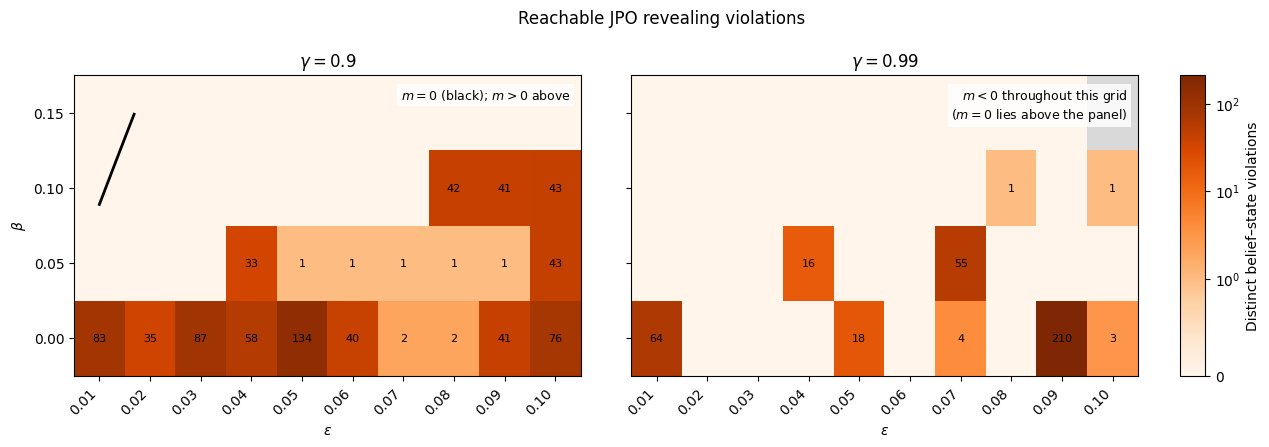

In [54]:
facet_heatmap('violation_count', 'Reachable JPO revealing violations', 'Distinct belief–state violations', '01_violation_count.png', 'Oranges', scale='symlog', linthresh=1.0, annotate_nonzero=True, show_margin=True)

## Figure 2 — Discounted transmission occupancy

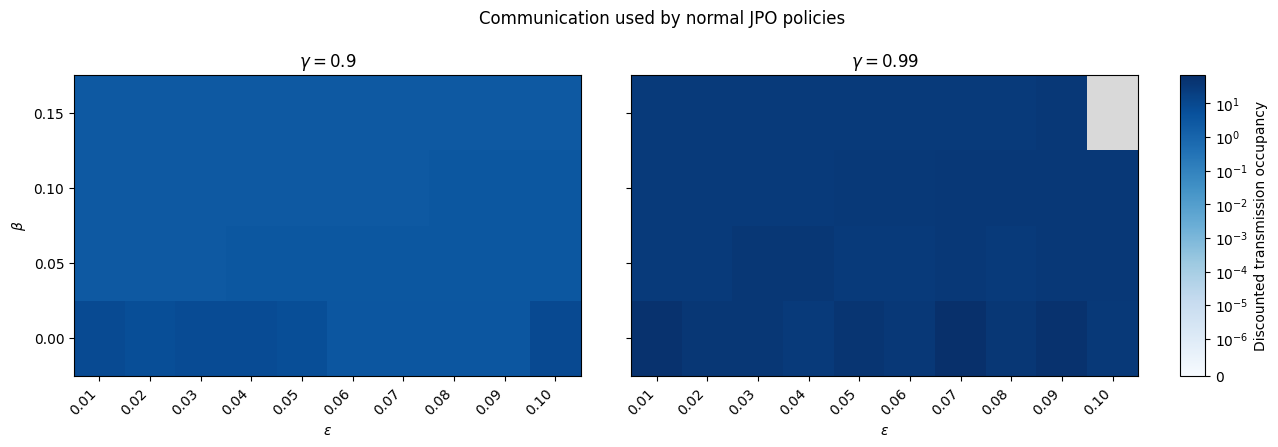

In [55]:
facet_heatmap('discounted_transmission_occupancy', 'Communication used by normal JPO policies', 'Discounted transmission occupancy', '02_transmission_occupancy.png', 'Blues', scale='symlog', linthresh=1e-6)

## Figure 3 — Normal extracted-policy value

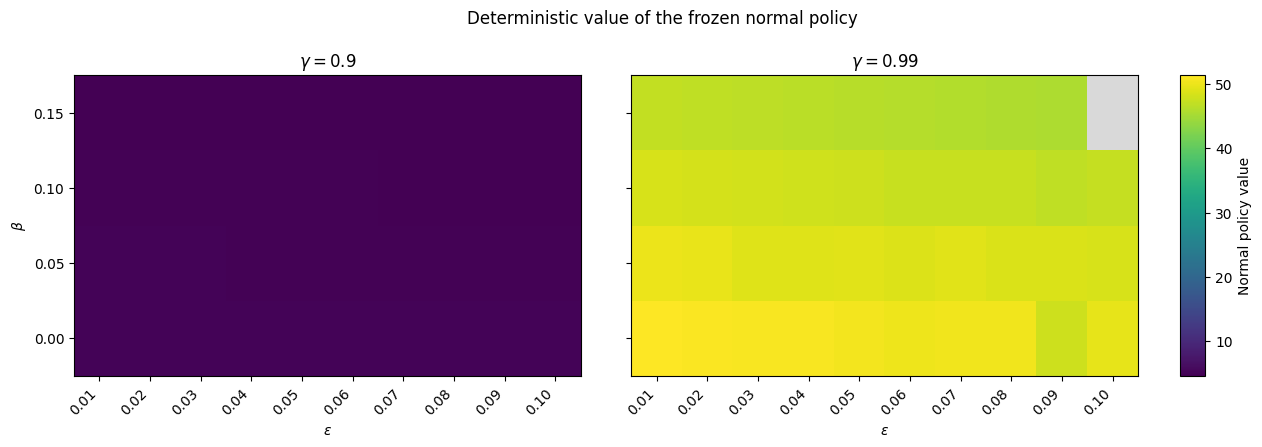

In [56]:
facet_heatmap('normal_policy_value', 'Deterministic value of the frozen normal policy', 'Normal policy value', '03_normal_policy_value.png', 'viridis')

## Figures 4a–4d — Normal and restricted values at fixed $\beta$

Each figure fixes one sampled $\beta$ and uses $\epsilon$ on the horizontal axis. The solid curve is the deterministically evaluated normal JPO policy value. The dashed restricted-scheme curve is present only at points with reachable violations, because that controller is only constructed in those cases. Red and green circles identify violating and violation-free normal policies respectively. Separate panels are used for each $\gamma$ so that the very different discounted-value scales remain readable.

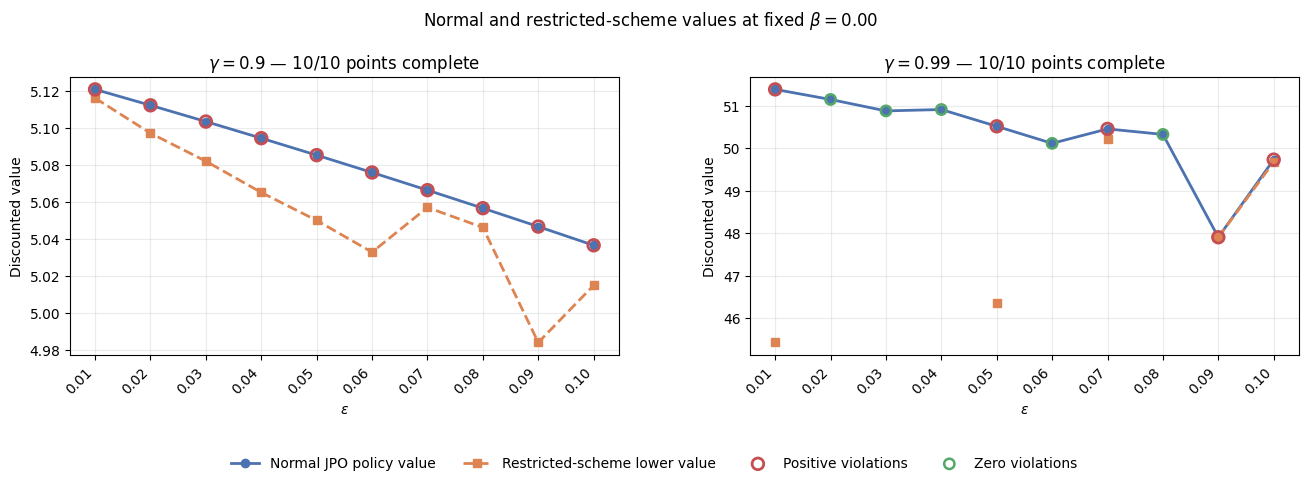

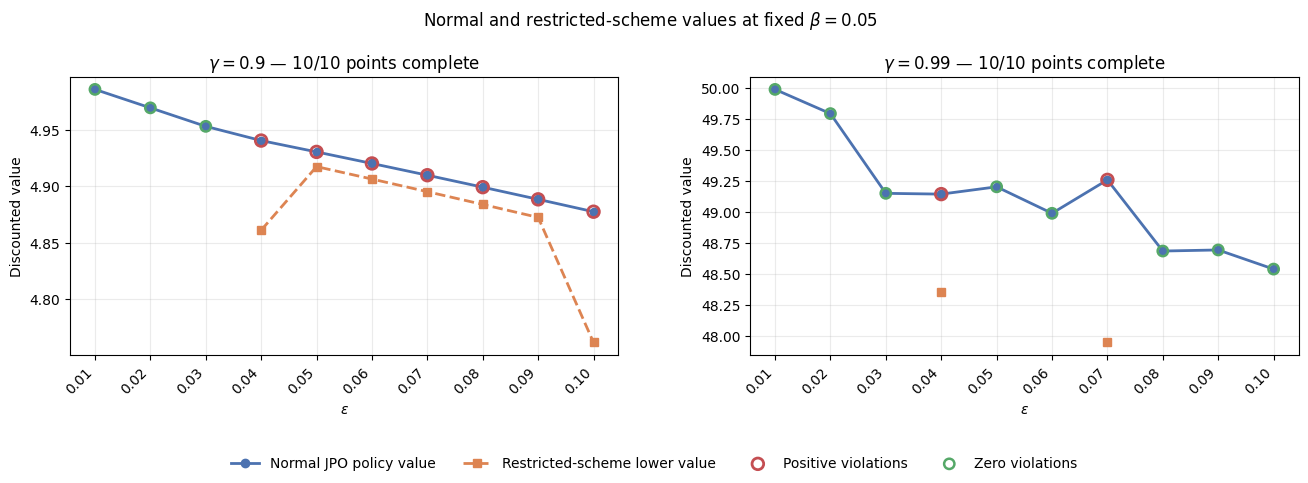

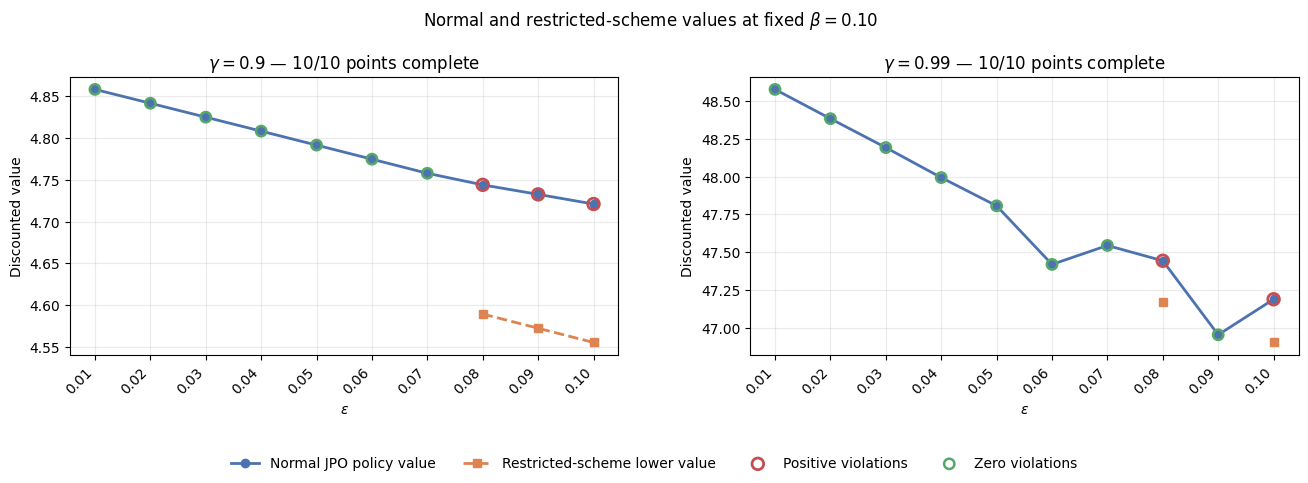

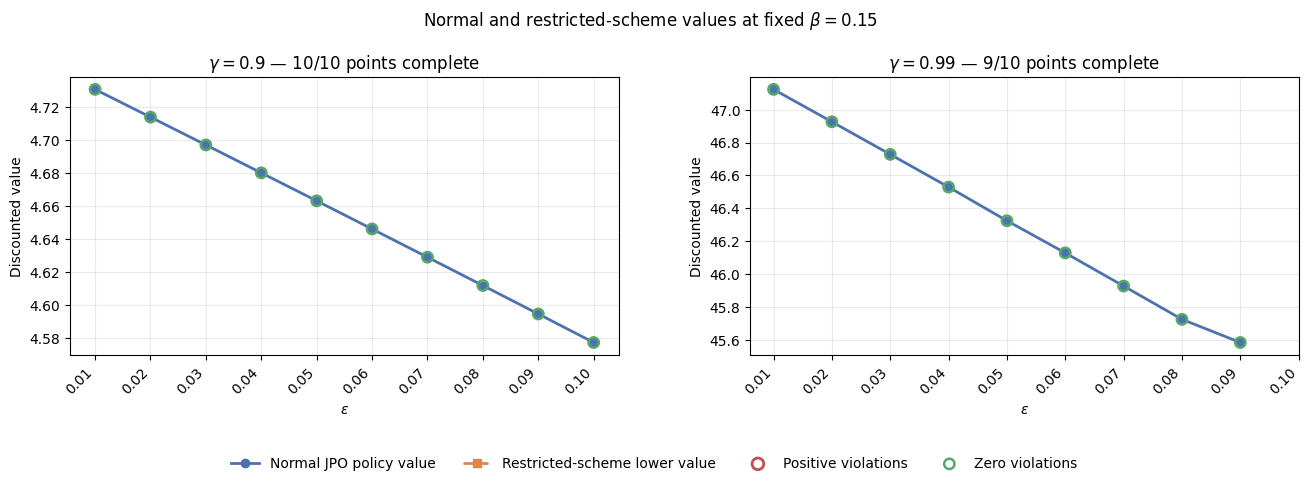

In [57]:
def plot_values_at_fixed_beta(beta):
    fig, axes = plt.subplots(1, len(gammas), figsize=(13.5, 4.8), squeeze=False)
    axes = axes.ravel()
    for ax, gamma in zip(axes, gammas):
        case = (
            frame[np.isclose(frame['beta'], beta) & np.isclose(frame['gamma'], gamma)]
            .sort_values('epsilon')
        )
        if case.empty:
            ax.text(0.5, 0.5, 'No completed points yet', transform=ax.transAxes, ha='center', va='center')
            ax.set_title(rf'$\gamma={gamma:g}$')
            ax.set_xlabel(r'$\epsilon$')
            continue
        ax.plot(
            case['epsilon'], case['normal_policy_value'],
            color='#4c72b0', marker='o', linewidth=2.0,
            label='Normal JPO policy value',
        )
        ax.plot(
            case['epsilon'], case['restricted_policy_lower_bound'],
            color='#dd8452', marker='s', linestyle='--', linewidth=2.0,
            label='Restricted-scheme lower value',
        )
        violating_case = case[case['violation_count'] > 0]
        revealing_case = case[case['violation_count'] == 0]
        ax.scatter(
            violating_case['epsilon'], violating_case['normal_policy_value'],
            s=70, facecolors='none', edgecolors='#c44e52', linewidths=2.0, zorder=5,
            label='Positive violations',
        )
        ax.scatter(
            revealing_case['epsilon'], revealing_case['normal_policy_value'],
            s=55, facecolors='none', edgecolors='#55a868', linewidths=1.8, zorder=5,
            label='Zero violations',
        )
        ax.set_title(rf'$\gamma={gamma:g}$ — {len(case)}/{len(epsilons)} points complete')
        ax.set_xlabel(r'$\epsilon$')
        ax.set_ylabel('Discounted value')
        ax.set_xticks(epsilons, [f'{value:.2f}' for value in epsilons], rotation=45, ha='right')
        ax.grid(alpha=0.25)
    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    fig.legend(by_label.values(), by_label.keys(), loc='lower center', ncol=4, frameon=False)
    fig.suptitle(rf'Normal and restricted-scheme values at fixed $\beta={beta:.2f}$')
    fig.subplots_adjust(left=0.07, right=0.98, bottom=0.26, top=0.84, wspace=0.24)
    beta_tag = f'{beta:.2f}'.replace('.', 'p')
    fig.savefig(PLOTS / f'04_values_fixed_beta_{beta_tag}.png', dpi=180, bbox_inches='tight')
    plt.show()

for beta in betas:
    plot_values_at_fixed_beta(beta)

### Coverage of the fixed-$\beta$ comparisons

This compact table makes incomplete slices and the number of available restricted-scheme values explicit.

In [58]:
comparison_coverage = (
    frame.groupby(['beta', 'gamma'], as_index=False)
    .agg(
        completed=('point_id', 'size'),
        violating=('violation_count', lambda values: int((values > 0).sum())),
        restricted_values=('restricted_policy_lower_bound', 'count'),
    )
)
display(comparison_coverage)

,beta,gamma,completed,violating,restricted_values
0,0.00,0.90,10,10,10
1,0.00,0.99,10,5,5
2,0.05,0.90,10,7,7
3,0.05,0.99,10,2,2
4,0.10,0.90,10,3,3
5,0.10,0.99,10,2,2
6,0.15,0.90,10,0,0
7,0.15,0.99,9,0,0


## Figure 5 — Solver certificate gap and stopping status

Every completed cell reports the final NativeSARSOP certificate gap $U-L$. A red border marks a run that returned a policy after reaching the nominal 500-second time limit rather than the requested precision. An unbordered completed cell stopped by precision; a grey cell has not yet been produced by the experiment.

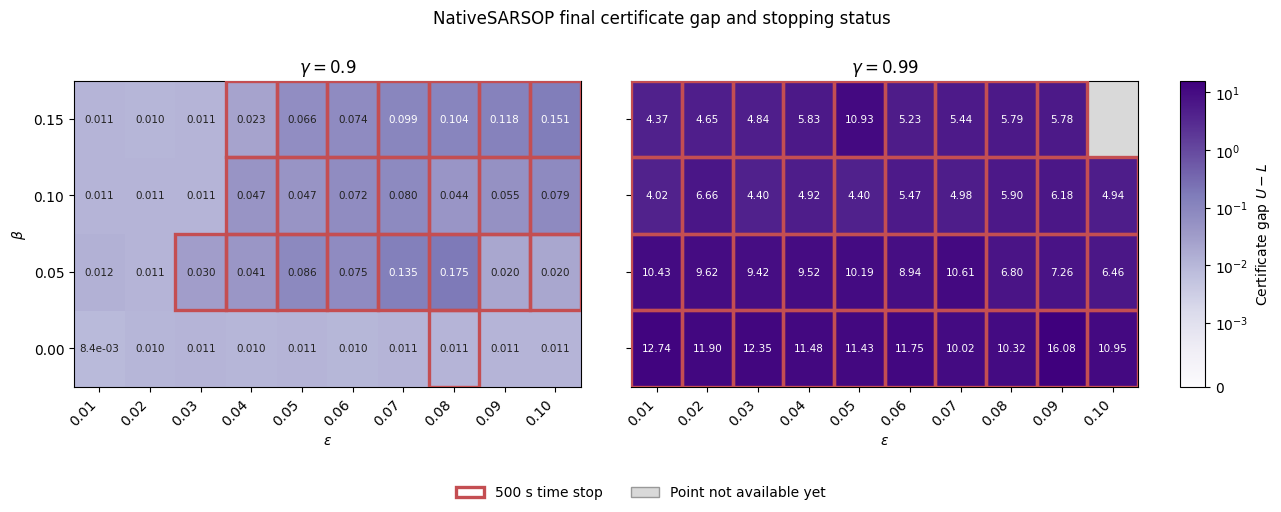

In [59]:
def format_solver_gap(value):
    if value >= 1.0:
        return f'{value:.2f}'
    if value >= 1e-2:
        return f'{value:.3f}'
    return f'{value:.1e}'

gap_matrices = [
    frame[frame['gamma'] == gamma].pivot(index='beta', columns='epsilon', values='sarsop_gap').reindex(index=betas, columns=epsilons)
    for gamma in gammas
]
stop_matrices = [
    frame[frame['gamma'] == gamma].pivot(index='beta', columns='epsilon', values='solver_stop_reason').reindex(index=betas, columns=epsilons)
    for gamma in gammas
]
finite_gaps = np.concatenate([matrix.to_numpy(dtype=float).ravel() for matrix in gap_matrices])
finite_gaps = finite_gaps[np.isfinite(finite_gaps)]
gap_norm = SymLogNorm(linthresh=1e-3, vmin=0.0, vmax=max(1e-3, float(finite_gaps.max())))
gap_cmap = plt.get_cmap('Purples').copy()
gap_cmap.set_bad('#d9d9d9')
fig, axes = plt.subplots(1, len(gammas), figsize=(14, 5.1), sharex=True, sharey=True)
for ax, gamma, gap_matrix, stop_matrix in zip(axes, gammas, gap_matrices, stop_matrices):
    gap_values = gap_matrix.to_numpy(dtype=float)
    stop_values = stop_matrix.to_numpy(dtype=object)
    image = ax.imshow(np.ma.masked_invalid(gap_values), origin='lower', aspect='auto', cmap=gap_cmap, norm=gap_norm)
    for row, column_index in np.argwhere(np.isfinite(gap_values)):
        gap = float(gap_values[row, column_index])
        text_color = 'white' if float(gap_norm(gap)) > 0.58 else '#222222'
        ax.text(column_index, row, format_solver_gap(gap), ha='center', va='center', fontsize=7.5, color=text_color)
        if stop_values[row, column_index] == 'max_time':
            ax.add_patch(Rectangle(
                (column_index - 0.5, row - 0.5), 1.0, 1.0,
                fill=False, edgecolor='#c44e52', linewidth=2.4, zorder=4,
            ))
    ax.set_title(rf'$\gamma={gamma:g}$')
    ax.set_xticks(range(len(epsilons)), [f'{value:.2f}' for value in epsilons], rotation=45, ha='right')
    ax.set_yticks(range(len(betas)), [f'{value:.2f}' for value in betas])
    ax.set_xlabel(r'$\epsilon$')
axes[0].set_ylabel(r'$\beta$')
fig.suptitle('NativeSARSOP final certificate gap and stopping status')
fig.subplots_adjust(left=0.08, right=0.84, bottom=0.24, top=0.84, wspace=0.10)
colorbar_axis = fig.add_axes([0.87, 0.24, 0.018, 0.60])
fig.colorbar(image, cax=colorbar_axis, label=r'Certificate gap $U-L$')
fig.legend(
    handles=[
        Patch(facecolor='none', edgecolor='#c44e52', linewidth=2.4, label='500 s time stop'),
        Patch(facecolor='#d9d9d9', edgecolor='#999999', label='Point not available yet'),
    ],
    loc='lower center', ncol=2, frameon=False,
)
fig.savefig(PLOTS / '05_solver_gap.png', dpi=180, bbox_inches='tight')
plt.show()

## Violating policies and conclusions

In [60]:
columns = [
    'gamma', 'beta', 'epsilon', 'margin', 'violation_count',
    'violation_discounted_event_occupancy', 'discounted_transmission_occupancy',
    'normal_policy_lower_bound', 'normal_policy_upper_bound', 'normal_policy_value',
    'restricted_policy_lower_bound', 'restricted_policy_upper_bound',
    'normal_minus_restricted_value', 'solver_stop_reason', 'sarsop_gap',
]
display(violating[columns].sort_values(['gamma', 'beta', 'epsilon']).round(8))
by_gamma = violating.groupby('gamma').size().reindex(gammas, fill_value=0)
completed_by_gamma = frame.groupby('gamma').size().reindex(gammas, fill_value=0)
time_limited = int((frame['solver_stop_reason'] == 'max_time').sum())
worst = violating.loc[violating['violation_count'].idxmax()] if len(violating) else None
largest_loss = violating.loc[violating['normal_minus_restricted_value'].idxmax()] if len(violating) else None
lines = [
    f'- **{len(violating)}/{len(frame)} completed** normal policies violate: ' + ', '.join(f'gamma={gamma:g}: {int(by_gamma.loc[gamma])}/{int(completed_by_gamma.loc[gamma])}' for gamma in gammas) + '.',
    f'- **{time_limited}/{len(frame)} completed** NativeSARSOP runs hit the nominal 500-second cap.',
]
if worst is not None:
    lines.append(rf'- The largest count is **{int(worst["violation_count"])}** at $\gamma={worst["gamma"]:g}$, $\beta={worst["beta"]:.2f}$, $\epsilon={worst["epsilon"]:.2f}$.')
if largest_loss is not None:
    lines.append(rf'- The largest normal-to-restricted value loss is **{largest_loss["normal_minus_restricted_value"]:.4g}** at $\gamma={largest_loss["gamma"]:g}$, $\beta={largest_loss["beta"]:.2f}$, $\epsilon={largest_loss["epsilon"]:.2f}$.')
display(Markdown('\n'.join(lines)))

,gamma,beta,epsilon,margin,violation_count,violation_discounted_event_occupancy,discounted_transmission_occupancy,normal_policy_lower_bound,normal_policy_upper_bound,normal_policy_value,restricted_policy_lower_bound,restricted_policy_upper_bound,normal_minus_restricted_value,solver_stop_reason,sarsop_gap
0,0.90,0.00,0.01,-0.0891,83,5.286400,7.864858,5.120773,5.121273,5.121023,5.116318,5.116818,0.004455,precision,0.008442
1,0.90,0.00,0.02,-0.1764,35,4.777407,6.577734,5.112175,5.112674,5.112424,5.097349,5.097849,0.014825,precision,0.010423
2,0.90,0.00,0.03,-0.2619,87,5.894339,7.791944,5.103375,5.103874,5.103625,5.082174,5.082674,0.021201,precision,0.010939
3,0.90,0.00,0.04,-0.3456,58,5.540261,7.498903,5.094384,5.094884,5.094634,5.065282,5.065782,0.029102,precision,0.010345
4,0.90,0.00,0.05,-0.4275,134,4.480014,6.456115,5.085203,5.085703,5.085453,5.050135,5.050635,0.035068,precision,0.010951
5,0.90,0.00,0.06,-0.5076,40,1.431478,3.275685,5.075832,5.076331,5.076081,5.032993,5.033493,0.042839,precision,0.010013
6,0.90,0.00,0.07,-0.5859,2,0.472615,3.286207,5.066270,5.066770,5.066520,5.057176,5.057676,0.009094,precision,0.010938
7,0.90,0.00,0.08,-0.6624,2,0.462502,3.296817,5.056518,5.057017,5.056768,5.046332,5.046832,0.010186,max_time,0.011031
8,0.90,0.00,0.09,-0.7371,41,1.380437,3.307518,5.046575,5.047075,5.046825,4.984128,4.984628,0.062447,precision,0.010835
9,0.90,0.00,0.10,-0.8100,76,5.556207,8.999983,5.036443,5.036942,5.036692,5.015050,5.015550,0.021392,precision,0.010838


- **29/79 completed** normal policies violate: gamma=0.9: 20/40, gamma=0.99: 9/39.
- **62/79 completed** NativeSARSOP runs hit the nominal 500-second cap.
- The largest count is **210** at $\gamma=0.99$, $\beta=0.00$, $\epsilon=0.09$.
- The largest normal-to-restricted value loss is **5.956** at $\gamma=0.99$, $\beta=0.00$, $\epsilon=0.01$.